# Tarea 3: Análisis del Inventario Arbóreo - Campus Omar Dengo UNA

**Curso:** Programación en SIG  
**Estudiante:** Adrián Delgado Torres  
**Fecha:** Junio 2026


## Introducción

El Campus Omar Dengo de la Universidad Nacional de Costa Rica (UNA) cuenta con un inventario arbóreo documentado mediante censos forestales periódicos desde 2018. Este conjunto de datos registra **más de 1,600 árboles individuales** con mediciones repetidas a lo largo de seis años (2018-2025).

Los datos combinan un archivo CSV con mediciones dendrométricas y estimaciones de carbono, y un GeoPackage con las coordenadas GPS reales de cada árbol levantadas en campo. Esta tarea extiende el análisis de la Tarea 2 incorporando **mapas interactivos** con folium para explorar la distribución espacial real de los árboles dentro del campus.

### Variables principales:

| Variable | Descripción | Unidad |
|---|---|---|
| `NUMERO ARBOL` | Identificador único del árbol | — |
| `NOMBRE COMUN` | Nombre común de la especie | — |
| `ESPECIE CIENTIFICA` | Nombre científico | — |
| `ANIO MEDICION` | Año del censo | 2018-2025 |
| `DAP CM` | Diámetro a la altura del pecho | cm |
| `ALTURA M` | Altura total del árbol | m |
| `BIOMASA TOTAL KG` | Biomasa total (aérea + radicular) | kg |
| `CARBONO TOTAL MG` | Carbono almacenado | Mg (toneladas) |
| `CO2 EQUIVALENTE MG` | CO₂ equivalente capturado | Mg CO₂e |
| `ESTADO ARBOL` | Estado del árbol | Activo / Removido |


## 1. Carga de bibliotecas y datos

In [1]:
# Instalación en Google Colab (omitir si trabaja en entorno local configurado)
# !pip install -U folium mapclassify geopandas

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import folium
from folium.plugins import MarkerCluster, HeatMap

pd.set_option('display.float_format', '{:,.2f}'.format)

In [3]:
# Cargar datos tabulares desde GitHub
url_csv = "https://raw.githubusercontent.com/adeltor11/Dashboard-Carbono-Campus-Omar-Dengo-UNA/main/inventario_arboreo_cod.csv"
datos = pd.read_csv(url_csv, encoding='utf-8')

# Cargar datos geoespaciales (GeoPackage con coordenadas GPS reales)
# Archivo local: COD_ARBOLES.gpkg (disponible en el repositorio del proyecto)
gdf_arboles = gpd.read_file("COD_ARBOLES.gpkg", layer='COD_ARBOLES')

print(f"Registros CSV: {len(datos):,}")
print(f"Árboles en GeoPackage: {len(gdf_arboles):,}")
datos.head(3)

Registros CSV: 8,192
Árboles en GeoPackage: 1,653


,NUMERO ARBOL,NOMBRE COMUN,ESPECIE CIENTIFICA,ANIO MEDICION,DAP CM,ALTURA M,BIOMASA TOTAL KG,CARBONO TOTAL MG,CO2 EQUIVALENTE MG,ESTADO ARBOL
0,1,Guayaba,Psidium guajava,2018,25.70,4.00,0.18,0.34,0.34,Activo
1,1,Guayaba,Psidium guajava,2019,27.50,4.00,0.21,0.39,0.39,Activo
2,2,Guayaba,Psidium guajava,2018,16.70,4.00,0.08,0.14,0.14,Activo


In [4]:
# Filtrar árboles activos del censo 2025
datos_2025 = datos[(datos['ANIO MEDICION'] == 2025) & (datos['ESTADO ARBOL'] == 'Activo')].copy()
datos_2025['NOMBRE COMUN'] = datos_2025['NOMBRE COMUN'].str.lower().str.strip()

# Unir coordenadas GPS con datos del censo 2025
# Clave de unión: N__Árbol (GeoPackage) == NUMERO ARBOL (CSV)
inventario = gdf_arboles.merge(
    datos_2025[['NUMERO ARBOL', 'DAP CM', 'ALTURA M', 'CARBONO TOTAL MG', 'CO2 EQUIVALENTE MG']],
    left_on='N__Árbol',
    right_on='NUMERO ARBOL',
    how='inner'
)

print(f"Árboles activos 2025 con coordenadas GPS: {len(inventario):,}")
inventario[['N__Árbol', 'Nombre_com', 'Especie', 'Y', 'X', 'DAP CM', 'CO2 EQUIVALENTE MG']].head()

Árboles activos 2025 con coordenadas GPS: 1,485


,N__Árbol,Nombre_com,Especie,Y,X,DAP CM,CO2 EQUIVALENTE MG
0,1.00,guayaba,Psidium guajava,10.00,-84.11,31.70,1.40
1,"1,593.00",güitite,Acnistus arborescens,10.00,-84.11,11.80,0.13
2,2.00,guayaba,Psidium guajava,10.00,-84.11,23.50,0.49
3,3.00,poró gigante,Erythrina poeppigiana,10.00,-84.11,36.20,1.81
4,4.00,ciprés,Cupressus lusitanica,10.00,-84.11,63.50,7.52


## 2. Tabla con pandas: Resumen por especie (censo 2025)

Se agrupan los árboles activos del año más reciente (2025) por especie para obtener estadísticas descriptivas de las principales variables dendrométricas y de carbono.

In [5]:
tabla_especies = (
    datos_2025.groupby('NOMBRE COMUN')
    .agg(
        N_arboles=('NUMERO ARBOL', 'count'),
        DAP_promedio=('DAP CM', 'mean'),
        Altura_promedio=('ALTURA M', 'mean'),
        Carbono_total_Mg=('CARBONO TOTAL MG', 'sum'),
        CO2e_total_Mg=('CO2 EQUIVALENTE MG', 'sum')
    )
    .sort_values('N_arboles', ascending=False)
    .head(10)
    .reset_index()
)

tabla_especies.columns = ['Especie', 'N° árboles', 'DAP prom. (cm)',
                           'Altura prom. (m)', 'Carbono total (Mg)', 'CO₂e total (Mg)']
tabla_especies

,Especie,N° árboles,DAP prom. (cm),Altura prom. (m),Carbono total (Mg),CO₂e total (Mg)
0,mango,157,21.26,7.48,72.51,72.51
1,guachipelín,140,28.20,10.17,172.16,172.16
2,uruca,107,19.53,9.33,48.67,48.67
3,casco de venado,72,19.24,8.27,26.99,26.99
4,roblesabana,66,37.16,13.36,168.44,168.44
5,itabo,60,15.73,5.50,11.61,11.61
6,guayaba,59,16.03,9.04,14.44,14.44
7,higuerón,56,41.88,13.76,280.37,280.37
8,llama del bosque,44,29.25,12.64,63.22,63.22
9,jacaranda,43,31.04,12.36,73.90,73.90


### Interpretación:

La tabla muestra las 10 especies más frecuentes en el censo 2025. El **mango** (*Mangifera indica*) es la especie más abundante con 157 individuos, seguido del **guachipelín** (*Diphysa americana*) con 140. Destaca que el guachipelín, a pesar de tener un DAP promedio menor al del mango, acumula una cantidad significativa de carbono por su densidad de madera. El **higuerón** y el **roblesabana**, aunque menos numerosos, presentan los DAP más elevados, lo que refleja su mayor antigüedad y aporte individual a la biomasa total del campus.


## 3. Gráficos con matplotlib

### Gráfico 1: Frecuencia de las 10 especies más comunes (2025)

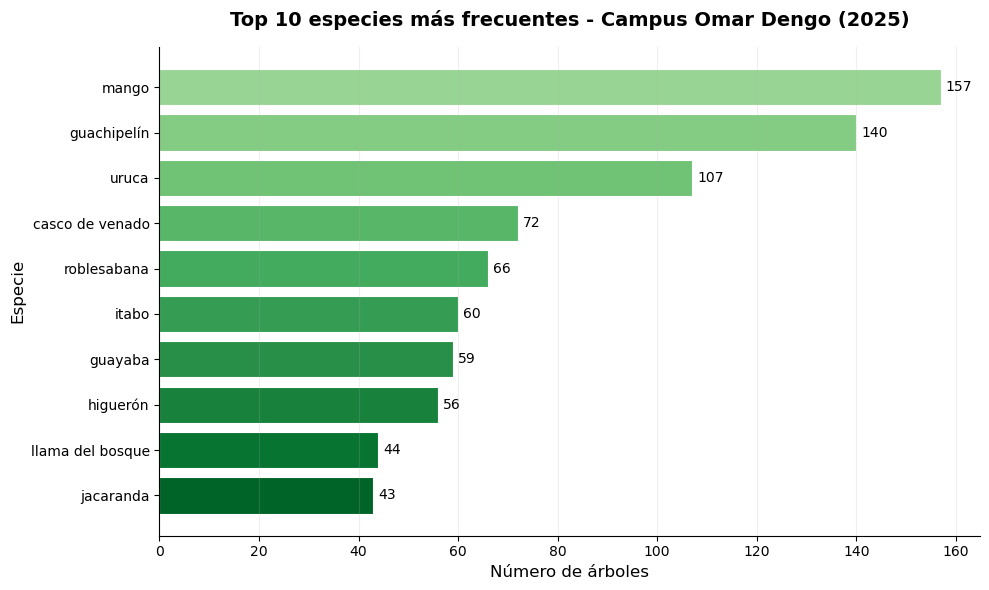

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

especies = tabla_especies['Especie']
n_arboles = tabla_especies['N° árboles']
colores = plt.cm.Greens(np.linspace(0.4, 0.9, len(especies)))

bars = ax.barh(especies[::-1], n_arboles[::-1], color=colores[::-1], edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, n_arboles[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10)

ax.set_title('Top 10 especies más frecuentes - Campus Omar Dengo (2025)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Número de árboles', fontsize=12)
ax.set_ylabel('Especie', fontsize=12)
ax.grid(True, axis='x', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

### Interpretación:

El gráfico de barras horizontales revela una distribución desigual entre especies. El mango y el guachipelín dominan claramente el inventario, concentrando casi el 20% de los árboles activos del campus entre ambas especies. Esta mezcla de especie exótica (mango) y nativa (guachipelín) es característica de los paisajes universitarios costarricenses. Las especies con menor frecuencia como cacao, jocote y níspero son principalmente frutales de presencia puntual.


### Gráfico 2: Distribución diamétrica (clases de DAP) - Árboles activos 2025

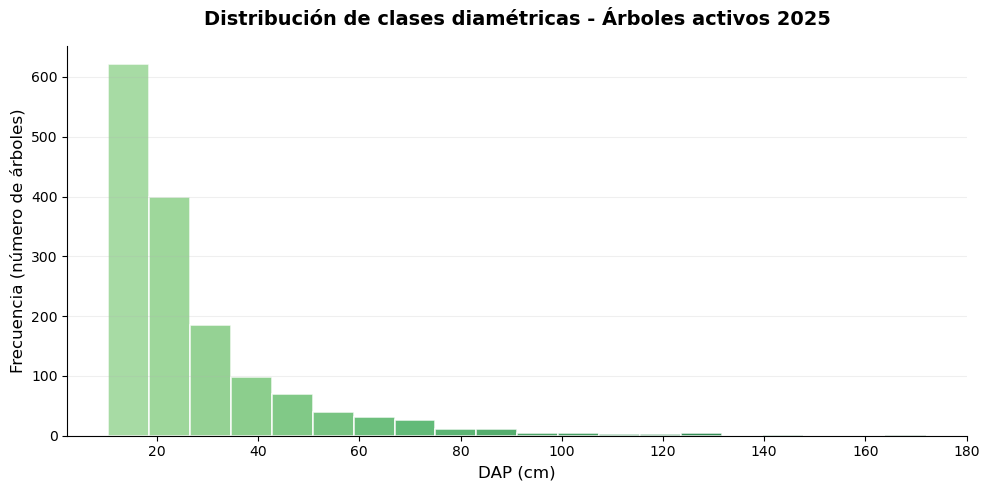

DAP promedio: 27.0 cm
DAP mediana:  20.5 cm
DAP máximo:   172.0 cm


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

n, bins, patches = ax.hist(datos_2025['DAP CM'].dropna(), bins=20,
                            color='#2d5f3f', edgecolor='white', linewidth=1.2, alpha=0.85)

cm = plt.cm.Greens
for i, patch in enumerate(patches):
    patch.set_facecolor(cm(0.4 + 0.6 * i / len(patches)))

ax.set_title('Distribución de clases diamétricas - Árboles activos 2025',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('DAP (cm)', fontsize=12)
ax.set_ylabel('Frecuencia (número de árboles)', fontsize=12)
ax.grid(True, axis='y', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

print(f"DAP promedio: {datos_2025['DAP CM'].mean():.1f} cm")
print(f"DAP mediana:  {datos_2025['DAP CM'].median():.1f} cm")
print(f"DAP máximo:   {datos_2025['DAP CM'].max():.1f} cm")

### Interpretación:

El histograma muestra una distribución sesgada hacia la derecha, típica de bosques urbanos con predominancia de individuos jóvenes a medianos. La mayor concentración de árboles se encuentra en la clase de 10-30 cm de DAP. La presencia de pocos árboles con DAP superiores a 80 cm corresponde a individuos maduros de alto valor ecológico (higuerón, roblesabana), que aunque son escasos en número, contribuyen de forma desproporcionada al carbono total almacenado.


## 4. Mapas interactivos con folium

Los mapas utilizan las **coordenadas GPS reales** de cada árbol, obtenidas del levantamiento de campo registrado en el GeoPackage `COD_ARBOLES.gpkg`. Las columnas `Y` (latitud) y `X` (longitud) corresponden al sistema de coordenadas geográficas WGS84 derivado de las coordenadas originales en CRTM05 (EPSG:5367).

### Mapa 1: Distribución de árboles en el campus (puntos con agrupamiento)

Este mapa muestra la ubicación real de cada árbol activo del censo 2025 mediante marcadores circulares. Se usa `MarkerCluster` para agrupar los puntos a escalas pequeñas y facilitar la navegación. Cada marcador incluye una ventana emergente (*popup*) con los datos del árbol y un *tooltip* con el nombre de la especie.

In [8]:
# Centro del mapa: promedio de coordenadas reales
lat_centro = inventario['Y'].mean()
lon_centro = inventario['X'].mean()

m1 = folium.Map(
    location=[lat_centro, lon_centro],
    zoom_start=17,
    tiles='OpenStreetMap'
)

cluster = MarkerCluster().add_to(m1)

for _, arbol in inventario.iterrows():
    popup_html = f"""
    <b>N.° árbol:</b> {int(arbol['N__Árbol'])}<br>
    <b>Especie:</b> {arbol['Nombre_com']}<br>
    <b>Nombre científico:</b> <i>{arbol['Especie']}</i><br>
    <b>DAP:</b> {arbol['DAP CM']:.1f} cm<br>
    <b>Altura:</b> {arbol['ALTURA M']:.1f} m<br>
    <b>CO₂e:</b> {arbol['CO2 EQUIVALENTE MG']:.3f} Mg
    """
    folium.CircleMarker(
        location=[arbol['Y'], arbol['X']],
        radius=5,
        color='darkgreen',
        fill=True,
        fill_color='green',
        fill_opacity=0.6,
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=f"{arbol['Nombre_com']} ({arbol['Especie']})"
    ).add_to(cluster)

m1

### Interpretación:

El mapa de puntos muestra la distribución espacial real de los 1,485 árboles activos con coordenadas GPS del censo 2025. El agrupamiento de marcadores (*MarkerCluster*) permite identificar zonas de mayor densidad arbórea dentro del campus; al hacer clic sobre un grupo se puede ver el detalle de cada árbol individualmente: número, especie, DAP, altura y carbono equivalente. Se observa que la vegetación no se distribuye de forma uniforme, sino que tiende a concentrarse en zonas de parques, corredores y bordes del campus, con áreas menos densas correspondientes a infraestructura construida.


### Mapa 2: Densidad de carbono almacenado (mapa de calor)

Este mapa muestra qué zonas del campus concentran mayor biomasa y aporte de carbono. A diferencia del mapa anterior, que representa la presencia de cada árbol de forma individual, el mapa de calor pondera cada punto por el valor de CO₂ equivalente del árbol, revelando los núcleos de mayor acumulación de biomasa.

In [9]:
m2 = folium.Map(
    location=[lat_centro, lon_centro],
    zoom_start=17,
    tiles='CartoDB positron'
)

# Datos para el heatmap: [lat, lon, peso]
datos_heat = inventario[['Y', 'X', 'CO2 EQUIVALENTE MG']].dropna()
heat_data = datos_heat.values.tolist()

HeatMap(
    heat_data,
    min_opacity=0.4,
    radius=20,
    blur=15,
    gradient={0.4: 'blue', 0.65: 'lime', 1: 'red'}
).add_to(m2)

# Leyenda
leyenda_html = '''
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background-color: white; padding: 10px 15px; border-radius: 6px;
     border: 1px solid #ccc; font-size: 13px;">
  <b>Densidad de CO₂e almacenado</b><br>
  <span style="color:blue">■</span> Baja &nbsp;
  <span style="color:lime">■</span> Media &nbsp;
  <span style="color:red">■</span> Alta
</div>
'''
m2.get_root().html.add_child(folium.Element(leyenda_html))

m2

### Interpretación:

El mapa de calor revela que el carbono no se distribuye de forma homogénea en el campus. Los núcleos de color rojo-naranja corresponden a sectores donde se agrupan árboles de gran porte o de especies con alta densidad de madera (higuerón, roblesabana, guachipelín), que son los principales reservorios de carbono. Estos núcleos tienen especial relevancia para la gestión del patrimonio arbóreo y para los compromisos de carbono neutralidad ante el PPCN 2.0: su conservación prioritaria garantiza el mantenimiento de la mayor parte del carbono almacenado en el campus.


## 5. Conclusiones

Este análisis del inventario arbóreo del Campus Omar Dengo incorpora herramientas de visualización espacial con coordenadas GPS reales que complementan el análisis tabular y gráfico de la Tarea 2:

1. **Diversidad florística**: Las 10 especies más frecuentes en 2025 concentran más del 60% del inventario activo, con el mango y el guachipelín como las especies dominantes.

2. **Estructura diamétrica**: La distribución de DAP muestra una población joven con predominancia de árboles de 10-30 cm, indicativa de un ecosistema urbano en crecimiento activo.

3. **Distribución espacial real**: El mapa de puntos con coordenadas GPS permite identificar con precisión las zonas de mayor densidad arbórea y consultar los atributos de cada árbol individualmente.

4. **Concentración de carbono**: El mapa de calor revela núcleos específicos de alta acumulación de biomasa, asociados a árboles maduros de especies como el higuerón y el roblesabana, cuya conservación es prioritaria para los objetivos de carbono neutralidad institucional.

5. **Valor para la gestión**: La combinación de análisis estadístico, cartografía interactiva y coordenadas reales constituye una herramienta práctica para la toma de decisiones en la gestión sostenible del patrimonio arbóreo y el cumplimiento de los compromisos ante el PPCN 2.0.
